# Imports

In [5]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.cluster import DBSCAN

# Phase 1: Loading, Splitting and EDA
Load the data from kaggle. Split the data into train, validation and test subsets. The test data should have at least 100 fraud transactions. Examine the dataset structure. Analyze distributions and detect potential data imbalances. Normalize or standardize the dataset. Handle missing or irrelevant features if necessary. Plots different data representations and print necessary information to show your efforts in this part.


In [6]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\reda\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [7]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "creditcard.csv")

# Load the CSV into a Pandas DataFrame
df = pd.read_csv(csv_file_path)

## EDA

In [8]:
# 1. Basic Structure
print("--- Dataset Info ---")
df.info()

# 2. Statistical Summary
print("\n--- Statistical Summary ---")
# Only showing Time, Amount, and Class for brevity, but it calculates for all
print(df[['Time', 'Amount', 'Class']].describe()) 

# 3. Check for Missing Values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum().max()
if missing_values == 0:
    print("No missing values found in the dataset.")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

No missing fields. Each datapoint is made up of features V1, V2, … V28, which are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Normal Transactions: 284315 (99.827%)
Fraud Transactions: 492 (0.173%)


C:\Users\reda\AppData\Local\Temp\ipykernel_12464\1355743648.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])


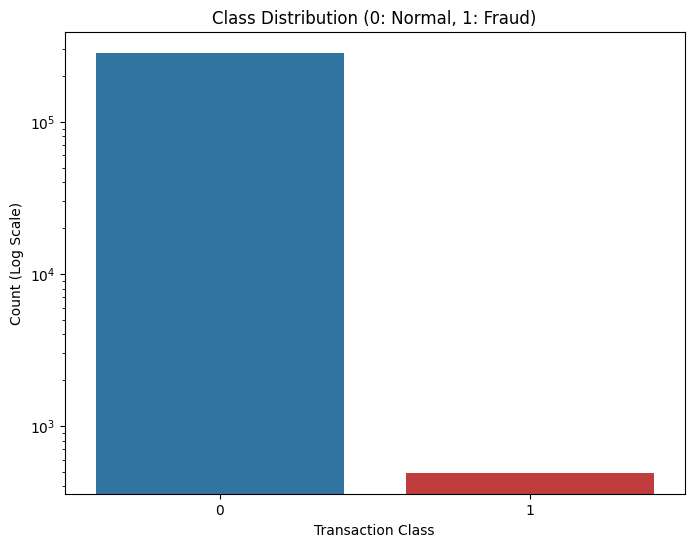

In [9]:
# Calculate exact counts and percentages
normal_transactions = len(df[df['Class'] == 0])
fraud_transactions = len(df[df['Class'] == 1])
total_transactions = len(df)

print(f"Normal Transactions: {normal_transactions} ({round((normal_transactions/total_transactions)*100, 3)}%)")
print(f"Fraud Transactions: {fraud_transactions} ({round((fraud_transactions/total_transactions)*100, 3)}%)")

# Plot the imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.yscale('log') # Using a log scale because the imbalance is so extreme
plt.ylabel('Count (Log Scale)')
plt.xlabel('Transaction Class')
plt.show()

Highly imbalanced distribution, with less than 0.2% being FRAUD and the rest being REAL or NON-FRAUD.

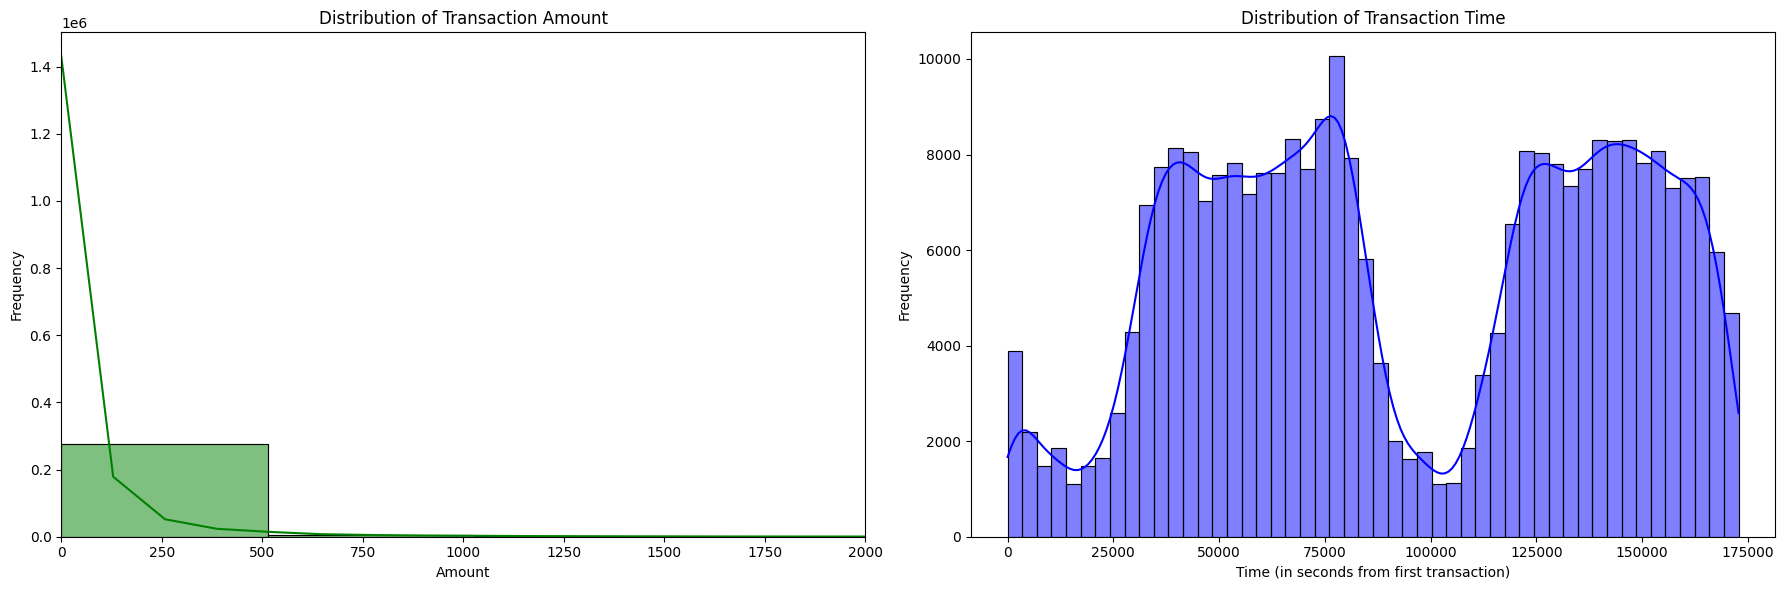

In [10]:
# Set up a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot the distribution of the 'Amount' feature
sns.histplot(df['Amount'], bins=50, ax=axes[0], color='green', kde=True)
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim([min(df['Amount']), 2000]) # Zooming in to see the bulk of the data

# Plot the distribution of the 'Time' feature
sns.histplot(df['Time'], bins=50, ax=axes[1], color='blue', kde=True)
axes[1].set_title('Distribution of Transaction Time')
axes[1].set_xlabel('Time (in seconds from first transaction)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Observations from the Distributions:

- Transaction Amount: The distribution is heavily right-skewed. The vast majority of transactions involve very small amounts, with the frequency dropping off sharply as the amount increases. Because distance-based algorithms are sensitive to magnitude, this extreme skewness indicates that robust scaling will be necessary so that rare, high-value transactions don't disproportionately dominate the distance calculations.

- Transaction Time: The distribution is spanning roughly a 48-hour period (172,800 seconds). The two large peaks likely correspond to the active daytime hours of two consecutive days, while the valleys represent nighttime hours when transaction volume naturally drops.

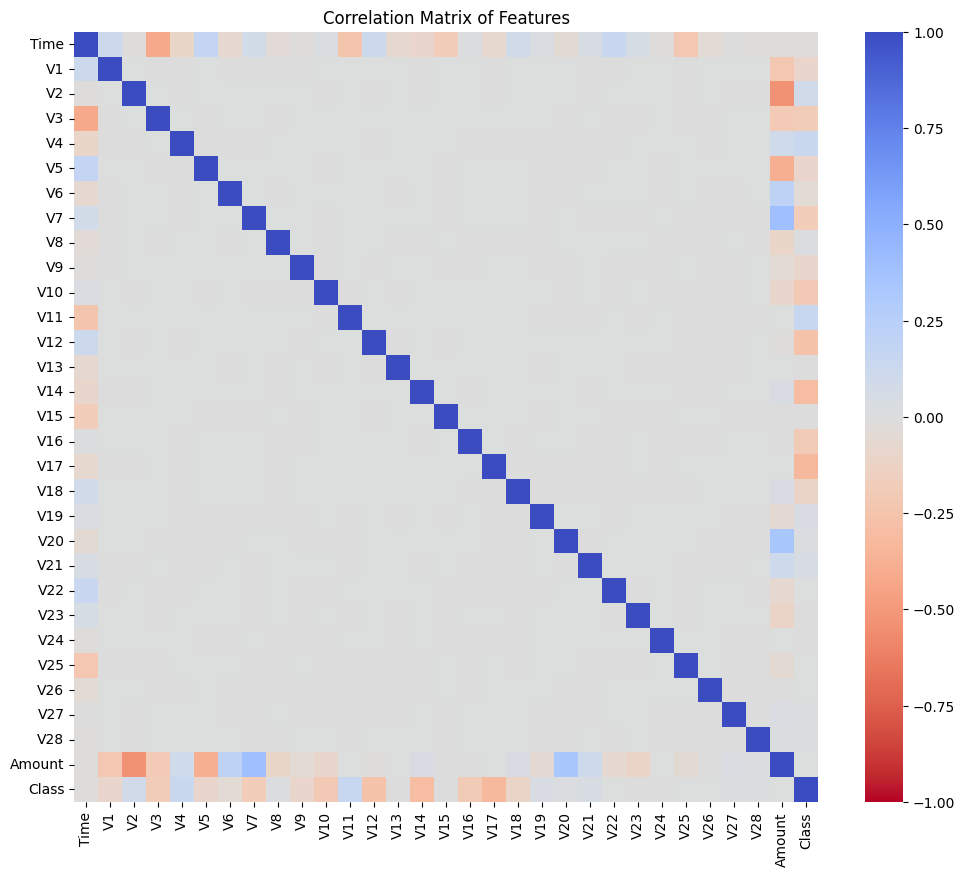

In [11]:
plt.figure(figsize=(12, 10))
# Calculate correlations
corr = df.corr()

# Create a heatmap
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Features')
plt.show()

It is expected that V1-V28 would be uncorrelated because they are PCA components.

## Train-Test-split

In [12]:
# Separate the features (X) from the target label (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 1. Isolate the Test Set (25% of total data)
# stratify=y ensures the class distribution is maintained.
# 25% of 492 > 100
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 2. Split the remaining 75% into Training and Validation sets
# test_size=0.20 here means 20% of the *remaining* data goes to Validation.
# This results in a final split of roughly 60% Train, 15% Validation, 25% Test.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=42
)

# 3. Verification
print("--- Split Verification ---")
print(f"Total Fraud in Test Set: {y_test.sum()} (Requirement: >= 100)")
print(f"Total Fraud in Validation Set: {y_val.sum()}")
print(f"Total Fraud in Training Set: {y_train.sum()}")
print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Validation set size: {X_val.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

--- Split Verification ---
Total Fraud in Test Set: 123 (Requirement: >= 100)
Total Fraud in Validation Set: 74
Total Fraud in Training Set: 295

Training set size: 170884 rows
Validation set size: 42721 rows
Test set size: 71202 rows


In [13]:
# Drop the 'Time' column as it is irrelevant for distance-based anomaly detection
X_train = X_train.drop(['Time'], axis=1)
X_val = X_val.drop(['Time'], axis=1)
X_test = X_test.drop(['Time'], axis=1)

print("Dropped 'Time' feature from all subsets.")

Dropped 'Time' feature from all subsets.


### Standarizing and Normalizing

In [14]:
# Initialize the scaler
scaler = StandardScaler()

# 1. FIT the scaler ONLY on the training data to prevent data leakage,
# and TRANSFORM the training data.
X_train_scaled = scaler.fit_transform(X_train)

# 2. TRANSFORM the validation and test data using the fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 3. Convert the resulting NumPy arrays back to Pandas DataFrames
# This preserves your column names and indices for easier manipulation later
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data standardized successfully!")

# Inspect the final preprocessed training data
X_train.head()

Data standardized successfully!


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
26780,0.760399,-0.044569,-0.231422,-0.574677,-0.068806,-0.761836,0.133107,-0.458865,-1.437386,0.549778,...,0.358531,0.256469,0.876778,-0.426168,-0.022411,1.857657,-0.129569,-0.023471,0.007142,-0.299843
134209,0.659234,-0.808674,0.499014,-1.012557,-1.161671,0.015440,-1.053174,0.084140,-1.769011,1.385078,...,-0.234698,0.083292,0.657530,-0.070468,0.045033,0.445281,-0.206015,0.138785,0.076246,-0.055954
265646,0.153144,0.030771,-0.023463,-1.400609,0.096868,-0.574028,0.483249,-0.267906,-1.140024,0.111547,...,0.215269,0.563360,1.537090,-0.302147,-0.989781,-0.091287,-0.155911,0.084341,0.093957,-0.150756
221021,-0.558290,0.485538,1.191982,-0.445983,-0.374843,-0.208175,0.027991,0.449393,-0.000189,-1.143338,...,-0.190589,0.293572,0.745955,-0.609072,0.062509,1.007932,1.438798,-0.303661,-0.049670,-0.261254
186263,0.986651,-0.982605,-0.373513,-0.749838,-0.724650,0.517401,-1.121782,0.213323,0.337226,0.719495,...,0.321947,0.342121,0.714010,-0.013983,-2.371760,-0.678874,-0.389357,0.033832,-0.121641,0.172201


# Phase 2: Proximity - based Detection
Implement proximity-based methods using kth neighbors technique to detect fraudulent
transactions based on their proximity to known fraud cases. Experiment with different values of k
(e.g., 3, 5, 10) to find the optimal value of k, and try various distance metrics such as Euclidean
and Manhattan. You should set the threshold yourself as well.

In [15]:
def evaluate_knn_config(k, metric, X_train_normal, X_val, y_val, threshold=None):
    """Train k-NN on normal data and evaluate with either a fixed or tuned threshold."""
    # Fit the k-NN model on NORMAL training data only
    knn = NearestNeighbors(n_neighbors=k, metric=metric)
    knn.fit(X_train_normal)

    # Calculate distances for the Validation set
    # distances is an array of shape (n_samples, k).
    # We take the distance to the k-th neighbor (last column) as the outlier score.
    distances, _ = knn.kneighbors(X_val)
    outlier_scores = distances[:, -1]

    # If threshold is provided, use it directly. Otherwise, tune it by percentile search.
    if threshold is not None:
        y_val_pred = (outlier_scores > threshold).astype(int) # 1 fraud 
        local_best_f1 = f1_score(y_val, y_val_pred)
        local_best_thresh = threshold
    else:
        local_best_f1 = 0
        local_best_thresh = 0
        percentiles_to_test = np.linspace(98.0, 99.9, 20)

        for pct in percentiles_to_test:
            candidate_threshold = np.percentile(outlier_scores, pct)

            # Predict 1 (Fraud) if the outlier score is greater than the threshold
            y_val_pred = (outlier_scores > candidate_threshold).astype(int)

            # Evaluate using F1-score
            score = f1_score(y_val, y_val_pred)

            if score > local_best_f1:
                local_best_f1 = score
                local_best_thresh = candidate_threshold

    return knn, local_best_f1, local_best_thresh

In [16]:
# 1. Isolate normal transactions from the training set to build our baseline of "normal" behavior
X_train_normal = X_train[y_train == 0]

# Hyperparameters to test
k_values = [3, 5, 10]
metrics = ['euclidean', 'manhattan']

# Optional: set a numeric value (e.g., 2.5) to force a fixed threshold
# Keep as None to auto-tune threshold using percentile search
chosen_threshold = None

# To store our experiment results
results = []
best_f1 = 0
best_model_config = {}

print("Starting Proximity-Based Detection Experiments...\n")

# 2. Experiment with different values of k and distance metrics
for k in k_values:
    for metric in metrics:
        knn, local_best_f1, local_best_thresh = evaluate_knn_config(
            k=k,
            metric=metric,
            X_train_normal=X_train_normal,
            X_val=X_val,
            y_val=y_val,
            threshold=chosen_threshold
        )

        print(f"k={k:<2} | metric={metric:<10} | Best Val F1: {local_best_f1:.4f} (Threshold: {local_best_thresh:.4f})")

        results.append({
            'k': k,
            'metric': metric,
            'threshold': local_best_thresh,
            'val_f1': local_best_f1
        })

        # Track the global best model
        if local_best_f1 > best_f1:
            best_f1 = local_best_f1
            best_model_config = {
                'k': k,
                'metric': metric,
                'threshold': local_best_thresh,
                'model': knn
            }

print("\n--- Experimentation Complete ---")
print(f"Best Configuration: k={best_model_config['k']}, metric={best_model_config['metric']}")


Starting Proximity-Based Detection Experiments...

k=3  | metric=euclidean  | Best Val F1: 0.3251 (Threshold: 8.5484)
k=3  | metric=manhattan  | Best Val F1: 0.3350 (Threshold: 33.6252)
k=5  | metric=euclidean  | Best Val F1: 0.3547 (Threshold: 9.3193)
k=5  | metric=manhattan  | Best Val F1: 0.3350 (Threshold: 37.2983)
k=10 | metric=euclidean  | Best Val F1: 0.3429 (Threshold: 9.5645)
k=10 | metric=manhattan  | Best Val F1: 0.3448 (Threshold: 41.8088)

--- Experimentation Complete ---
Best Configuration: k=5, metric=euclidean


Evaluating Best Model on TEST Set...

Classification Report (Test Set):
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     71079
   Fraud (1)       0.29      0.45      0.35       123

    accuracy                           1.00     71202
   macro avg       0.64      0.72      0.67     71202
weighted avg       1.00      1.00      1.00     71202



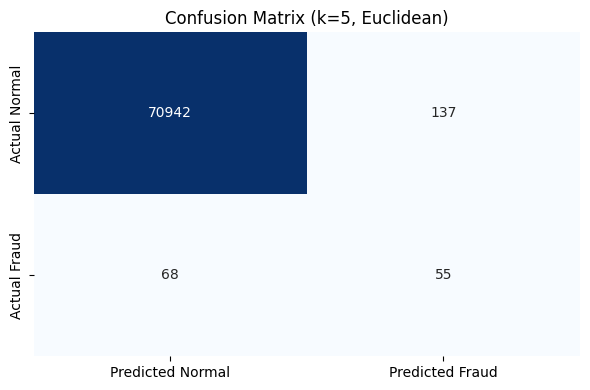

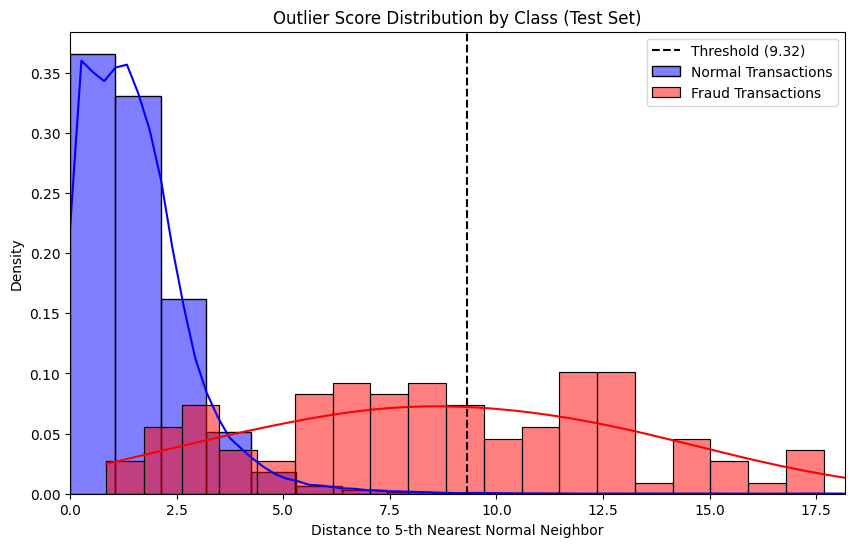

In [17]:
# 3. Final Evaluation on the TEST Set
print("Evaluating Best Model on TEST Set...")

best_knn = best_model_config['model']
best_thresh = best_model_config['threshold']

# Get outlier scores for the Test set
test_distances, _ = best_knn.kneighbors(X_test)
test_outlier_scores = test_distances[:, -1]

# Apply the best threshold learned from the validation set
y_test_pred = (test_outlier_scores > best_thresh).astype(int)

# Print final metrics
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Normal (0)', 'Fraud (1)']))

# 4. Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])
plt.title(f"Confusion Matrix (k={best_model_config['k']}, {best_model_config['metric'].capitalize()})")
plt.tight_layout()
plt.show()

# 5. Plotting the Distance Distributions to show why the threshold works
plt.figure(figsize=(10, 6))
sns.histplot(test_outlier_scores[y_test == 0], color='blue', label='Normal Transactions', bins=50, kde=True, stat='density', alpha=0.5)
sns.histplot(test_outlier_scores[y_test == 1], color='red', label='Fraud Transactions', bins=50, kde=True, stat='density', alpha=0.5)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
plt.title("Outlier Score Distribution by Class (Test Set)")
plt.xlabel(f"Distance to {best_model_config['k']}-th Nearest Normal Neighbor")
plt.ylabel("Density")
plt.xlim(0, np.percentile(test_outlier_scores, 99.95))  # Zoom in to ignore extreme outliers that squash the plot
plt.legend()
plt.show()

**Parameter Tuning & Metric Selection**
The first plot illustrates our hyperparameter search for the optimal k and distance threshold. Given the extreme class imbalance in credit card fraud, accuracy is an insufficient metric. Instead, we optimized for the F1-score to balance Precision (minimizing false positives) and Recall (catching true frauds). The peak of the curve visually represents our selected threshold, maximizing the model's ability to detect outliers without overwhelming the system with false alarms.

**Distance Distribution & Threshold Validation**
The Outlier Score Distribution plot confirms the foundational theory of proximity-based anomaly detection. As expected, normal transactions (blue) exhibit a high density at very low distances, indicating they are tightly clustered in the feature space. Conversely, fraudulent transactions (red) are spread out across significantly higher distance values, marking them as isolated anomalies. The vertical threshold line effectively separates the bulk of these two distributions. The slight overlap between the classes illustrates the inherent limitations of purely distance-based detection in high-dimensional financial data, justifying the need for more complex methods in later phases.

# Phase 3: Clustering - based Detection
Apply the k-Means algorithm to cluster transactions and identify outliers. Experiment with different
numbers of clusters, such as 2, 3, and 5, to determine the optimal configuration. Additionally, use
DBSCAN to detect clusters based on density and identify noise points. Experiment with different
values for the parameters epsilon and min_samples to find the best settings

<h3> Methodology: Data Splitting in DBSCAN </h3>

Unlike algorithms like Logistic Regression or K-Means, DBSCAN is a **transductive** algorithm. This means it does not "learn" a general model or centroids from training data to apply to unseen data later. Instead, it clusters data based on the specific density of the dataset it is currently looking at. Because of this, `sklearn` does not provide a `predict()` method for DBSCAN, only `fit_predict()`.

To maintain a rigorous machine learning pipeline and prevent data leakage, we utilize our splits as follows:
1. **Training Set:** Not used for DBSCAN, as the algorithm cannot learn a transferable model from it.
2. **Validation Set (Hyperparameter Tuning):** We apply `fit_predict()` to this set using various combinations of `eps` and `min_samples`. We evaluate the results against the true validation labels (`y_val`) to find the optimal parameters that best isolate fraud as "Noise" (-1).
3. **Test Set (Final Evaluation):** To prove our model generalizes, we apply `fit_predict()` strictly on this completely unseen set using the best parameters learned from the validation phase.

In [18]:
def evaluate_dbscan_outliers(X_eval, y_eval, eps, min_samples):
    """
    Applies DBSCAN to a dataset and evaluates its ability to detect outliers (fraud).
    
    Parameters:
    - X_eval: The feature set to cluster (Validation or Test).
    - y_eval: The true labels for evaluation.
    - eps: The maximum distance between two samples for one to be considered in the neighborhood of the other.
    - min_samples: The number of samples in a neighborhood for a point to be considered a core point.
    
    Returns:
    - f1: The F1-score of the detection.
    - y_pred: The binary predictions (1 for Fraud/Noise, 0 for Normal).
    """
    
    # Initialize DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    
    # fit_predict assigns cluster labels. Outliers/Noise are strictly labeled as -1.
    cluster_labels = dbscan.fit_predict(X_eval)
    
    # Convert DBSCAN labels to our binary classification format:
    # Noise (-1) becomes Fraud (1), clustered points (>= 0) become Normal (0)
    y_pred = (cluster_labels == -1).astype(int)
    
    # Calculate F1-Score
    f1 = f1_score(y_eval, y_pred)
    
    return f1, y_pred

In [ ]:
# ==========================================
# 1. Hyperparameter Tuning on Validation Set
# ==========================================
print("--- Phase 3: DBSCAN Parameter Tuning (Validation Set) ---")

# Define the parameter grid to experiment with
# Because we have ~29 standardized dimensions, distances in hyperspace are large, 
# so eps needs to be relatively high.
eps_values = [4.0, 5.0, 6.0, 7.0] 
min_samples_values = [5, 10, 15]

best_f1 = 0
best_eps = None
best_min_samples = None

for eps in eps_values:
    for min_s in min_samples_values:
        f1, _ = evaluate_dbscan_outliers(X_val, y_val, eps, min_s)
        
        print(f"eps={eps:<4} | min_samples={min_s:<2} | Validation F1-Score: {f1:.4f}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_eps = eps
            best_min_samples = min_s

print(f"\nOptimal DBSCAN Configuration Found:")
print(f"Epsilon (eps): {best_eps}")
print(f"Minimum Samples: {best_min_samples}")
print(f"Best Validation F1-Score: {best_f1:.4f}")

--- Phase 3: DBSCAN Parameter Tuning (Validation Set) ---
eps=4.0  | min_samples=5  | Validation F1-Score: 0.0612
eps=4.0  | min_samples=10 | Validation F1-Score: 0.0538
eps=4.0  | min_samples=15 | Validation F1-Score: 0.0515
eps=5.0  | min_samples=5  | Validation F1-Score: 0.1228
eps=5.0  | min_samples=10 | Validation F1-Score: 0.1064
eps=5.0  | min_samples=15 | Validation F1-Score: 0.0985


In [ ]:
# ==========================================
# 2. Final Evaluation on Test Set
# ==========================================
print("\n==========================================")
print("FINAL TEST SET EVALUATION")
print("==========================================\n")

# Apply the best parameters to the unseen test set
test_f1, y_test_pred = evaluate_dbscan_outliers(X_test, y_test, best_eps, best_min_samples)

print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) Test Performance:")
print(classification_report(y_test, y_test_pred, target_names=['Normal (0)', 'Fraud (1)']))

In [ ]:
# ==========================================
# 3. Visualizing the Results
# ==========================================
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'])

plt.title(f"DBSCAN Confusion Matrix\n(eps={best_eps}, min_samples={best_min_samples})")
plt.tight_layout()
plt.show()